In [1]:
# set up the python
import cosima_cookbook as cc
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid 

In [2]:
session = cc.database.create_session()

In [3]:
# time period
start_time='2159-01-01'
end_time='2159-12-31'
#load yearly MLD 
mld_ctrl = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='mld', 
                          session=session, frequency='1 monthly').sel(time = slice(start_time, end_time)).sel(yt_ocean = slice(-90,-50)).resample(time = '1Y').mean('time').load()
#land mask
land = xr.where(np.isnan(mld_ctrl[:,:].rename('land')), 1, np.nan)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(var, chunks, chunkmanager)

  var_chunks = _get_chunk(va

In [4]:
# load wind fields
uas_ctrl=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/V1-3/RYF.u_10.1990_1991.nc')
vas_ctrl=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/V1-3/RYF.v_10.1990_1991.nc')

uas_th=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/ssp585/RYF.u_10.1990_1991.nc')
vas_th=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/ssp585/RYF.v_10.1990_1991.nc')

In [5]:
tas_ctrl=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/V1-3/RYF.t_10.1990_1991.nc')

tas_th=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/ssp585/RYF.t_10.1990_1991.nc')

In [6]:
lw_ctrl=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/V1-3/RYF.rlds.1990_1991.nc')

lw_th=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/ssp585/RYF.rlds.1990_1991.nc')

In [7]:
rain_ctrl=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/V1-3/RYF.rain.1990_1991.nc')

rain_th=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/ssp585/RYF.rain.1990_1991.nc')

In [8]:
snow_ctrl=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/V1-3/RYF.snow.1990_1991.nc')

snow_th=xr.open_dataset('/g/data/e14/hd4873/access-om2-01/project03_cmip6_forcing/JRA55-do_input_files/ssp585/RYF.snow.1990_1991.nc')

In [9]:
rain_ctrl

<xarray.Dataset> Size: 2GB
Dimensions:    (latitude: 320, longitude: 640, time: 2920)
Coordinates:
  * latitude   (latitude) float64 3kB -89.57 -89.01 -88.45 ... 88.45 89.01 89.57
  * longitude  (longitude) float64 5kB 0.0 0.5625 1.125 ... 358.3 358.9 359.4
  * time       (time) object 23kB 1900-01-01 00:00:00 ... 1900-12-31 21:00:00
Data variables:
    prrn       (time, latitude, longitude) float32 2GB ...
Attributes:
    title:        Adjusted rain fall rate of JRA55-do
    institution:  JMA Meteorological Research Institute
    comment:      None
    version:      v1.3
    fill_value:   Fill value is -9.99e33

In [10]:
uas_ctrl = uas_ctrl.uas_10m
vas_ctrl = vas_ctrl.vas_10m
uas_th = uas_th.uas_10m
vas_th = vas_th.vas_10m
tas_ctrl = tas_ctrl.tas_10m
tas_th = tas_th.tas_10m
lw_ctrl = lw_ctrl.rlds
lw_th= lw_th.rlds
rain_ctrl = rain_ctrl.prrn
rain_th = rain_th.prrn
snow_ctrl = snow_ctrl.prsn
snow_th = snow_th.prsn

In [11]:
snow_th

<xarray.DataArray 'prsn' (time: 2920, latitude: 320, longitude: 640)> Size: 5GB
[598016000 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 3kB -89.57 -89.01 -88.45 ... 88.45 89.01 89.57
  * longitude  (longitude) float64 5kB 0.0 0.5625 1.125 ... 358.3 358.9 359.4
  * time       (time) object 23kB 1900-01-01 00:00:00 ... 1900-12-31 21:00:00

In [12]:
# annual mean 
uas_ctrl = uas_ctrl.sel(latitude = slice(-80,-50)).mean('time')
vas_ctrl = vas_ctrl.sel(latitude = slice(-80,-50)).mean('time')
uas_th= uas_th.sel(latitude = slice(-80,-50)).mean('time')
vas_th = vas_th.sel(latitude = slice(-80,-50)).mean('time')
tas_ctrl = tas_ctrl.sel(latitude = slice(-80,-50)).mean('time')
tas_th = tas_th.sel(latitude = slice(-80,-50)).mean('time')
lw_ctrl = lw_ctrl.sel(latitude = slice(-80,-50)).mean('time')
lw_th= lw_th.sel(latitude = slice(-80,-50)).mean('time')
rain_ctrl = rain_ctrl.sel(latitude = slice(-80,-50)).mean('time')
rain_th = rain_th.sel(latitude = slice(-80,-50)).mean('time')
snow_ctrl = snow_ctrl.sel(latitude = slice(-80,-50)).mean('time')
snow_th = snow_th.sel(latitude = slice(-80,-50)).mean('time')

In [13]:
vas_th-vas_ctrl

<xarray.DataArray 'vas_10m' (latitude: 53, longitude: 640)> Size: 271kB
array([[-0.12913481,  0.13658314,  0.12801094, ...,  0.13276279,
         0.13619452,  0.13677622],
       [-0.1234882 ,  0.13658372,  0.13432814, ...,  0.1381113 ,
         0.14099637,  0.1417018 ],
       [-0.13167195,  0.12624007,  0.12507278, ...,  0.12581887,
         0.12806436,  0.12860473],
       ...,
       [-0.16037269, -0.09891662, -0.10358389, ..., -0.09205996,
        -0.09310023, -0.09503734],
       [-0.13348191, -0.07131877, -0.07699602, ..., -0.06252674,
        -0.06402298, -0.06539643],
       [-0.1021132 , -0.03935338, -0.04530901, ..., -0.02699675,
        -0.03107952, -0.03232143]])
Coordinates:
  * latitude   (latitude) float64 424B -79.47 -78.91 -78.35 ... -50.83 -50.27
  * longitude  (longitude) float64 5kB 0.0 0.5625 1.125 ... 358.3 358.9 359.4

In [14]:
data = xr.Dataset({
    'Zonal wind Control': uas_ctrl,
    'Zonal wind SSP585': uas_th-uas_ctrl,
    'Meridional wind Control': vas_ctrl,
    'Meridional wind SSP585':vas_th-vas_ctrl,
    'Atmospheric temperature Control':tas_ctrl-273.15,
    'Atmospheric temperature SSP585':tas_th-tas_ctrl,
    'Surface downwelling longwave radiation Control':lw_ctrl,
    'Surface downwelling longwave radiation SSP585':lw_th-lw_ctrl,
    'Rainfall Control':rain_ctrl,
    'Rainfall SSP585':rain_th-rain_ctrl,
    'Snowfall Control':snow_ctrl,
    'Snowfall SSP585':snow_th-snow_ctrl
})

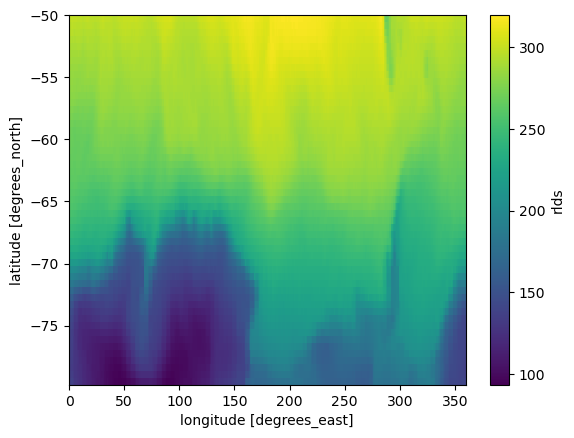

In [15]:
lw_ctrl.plot()

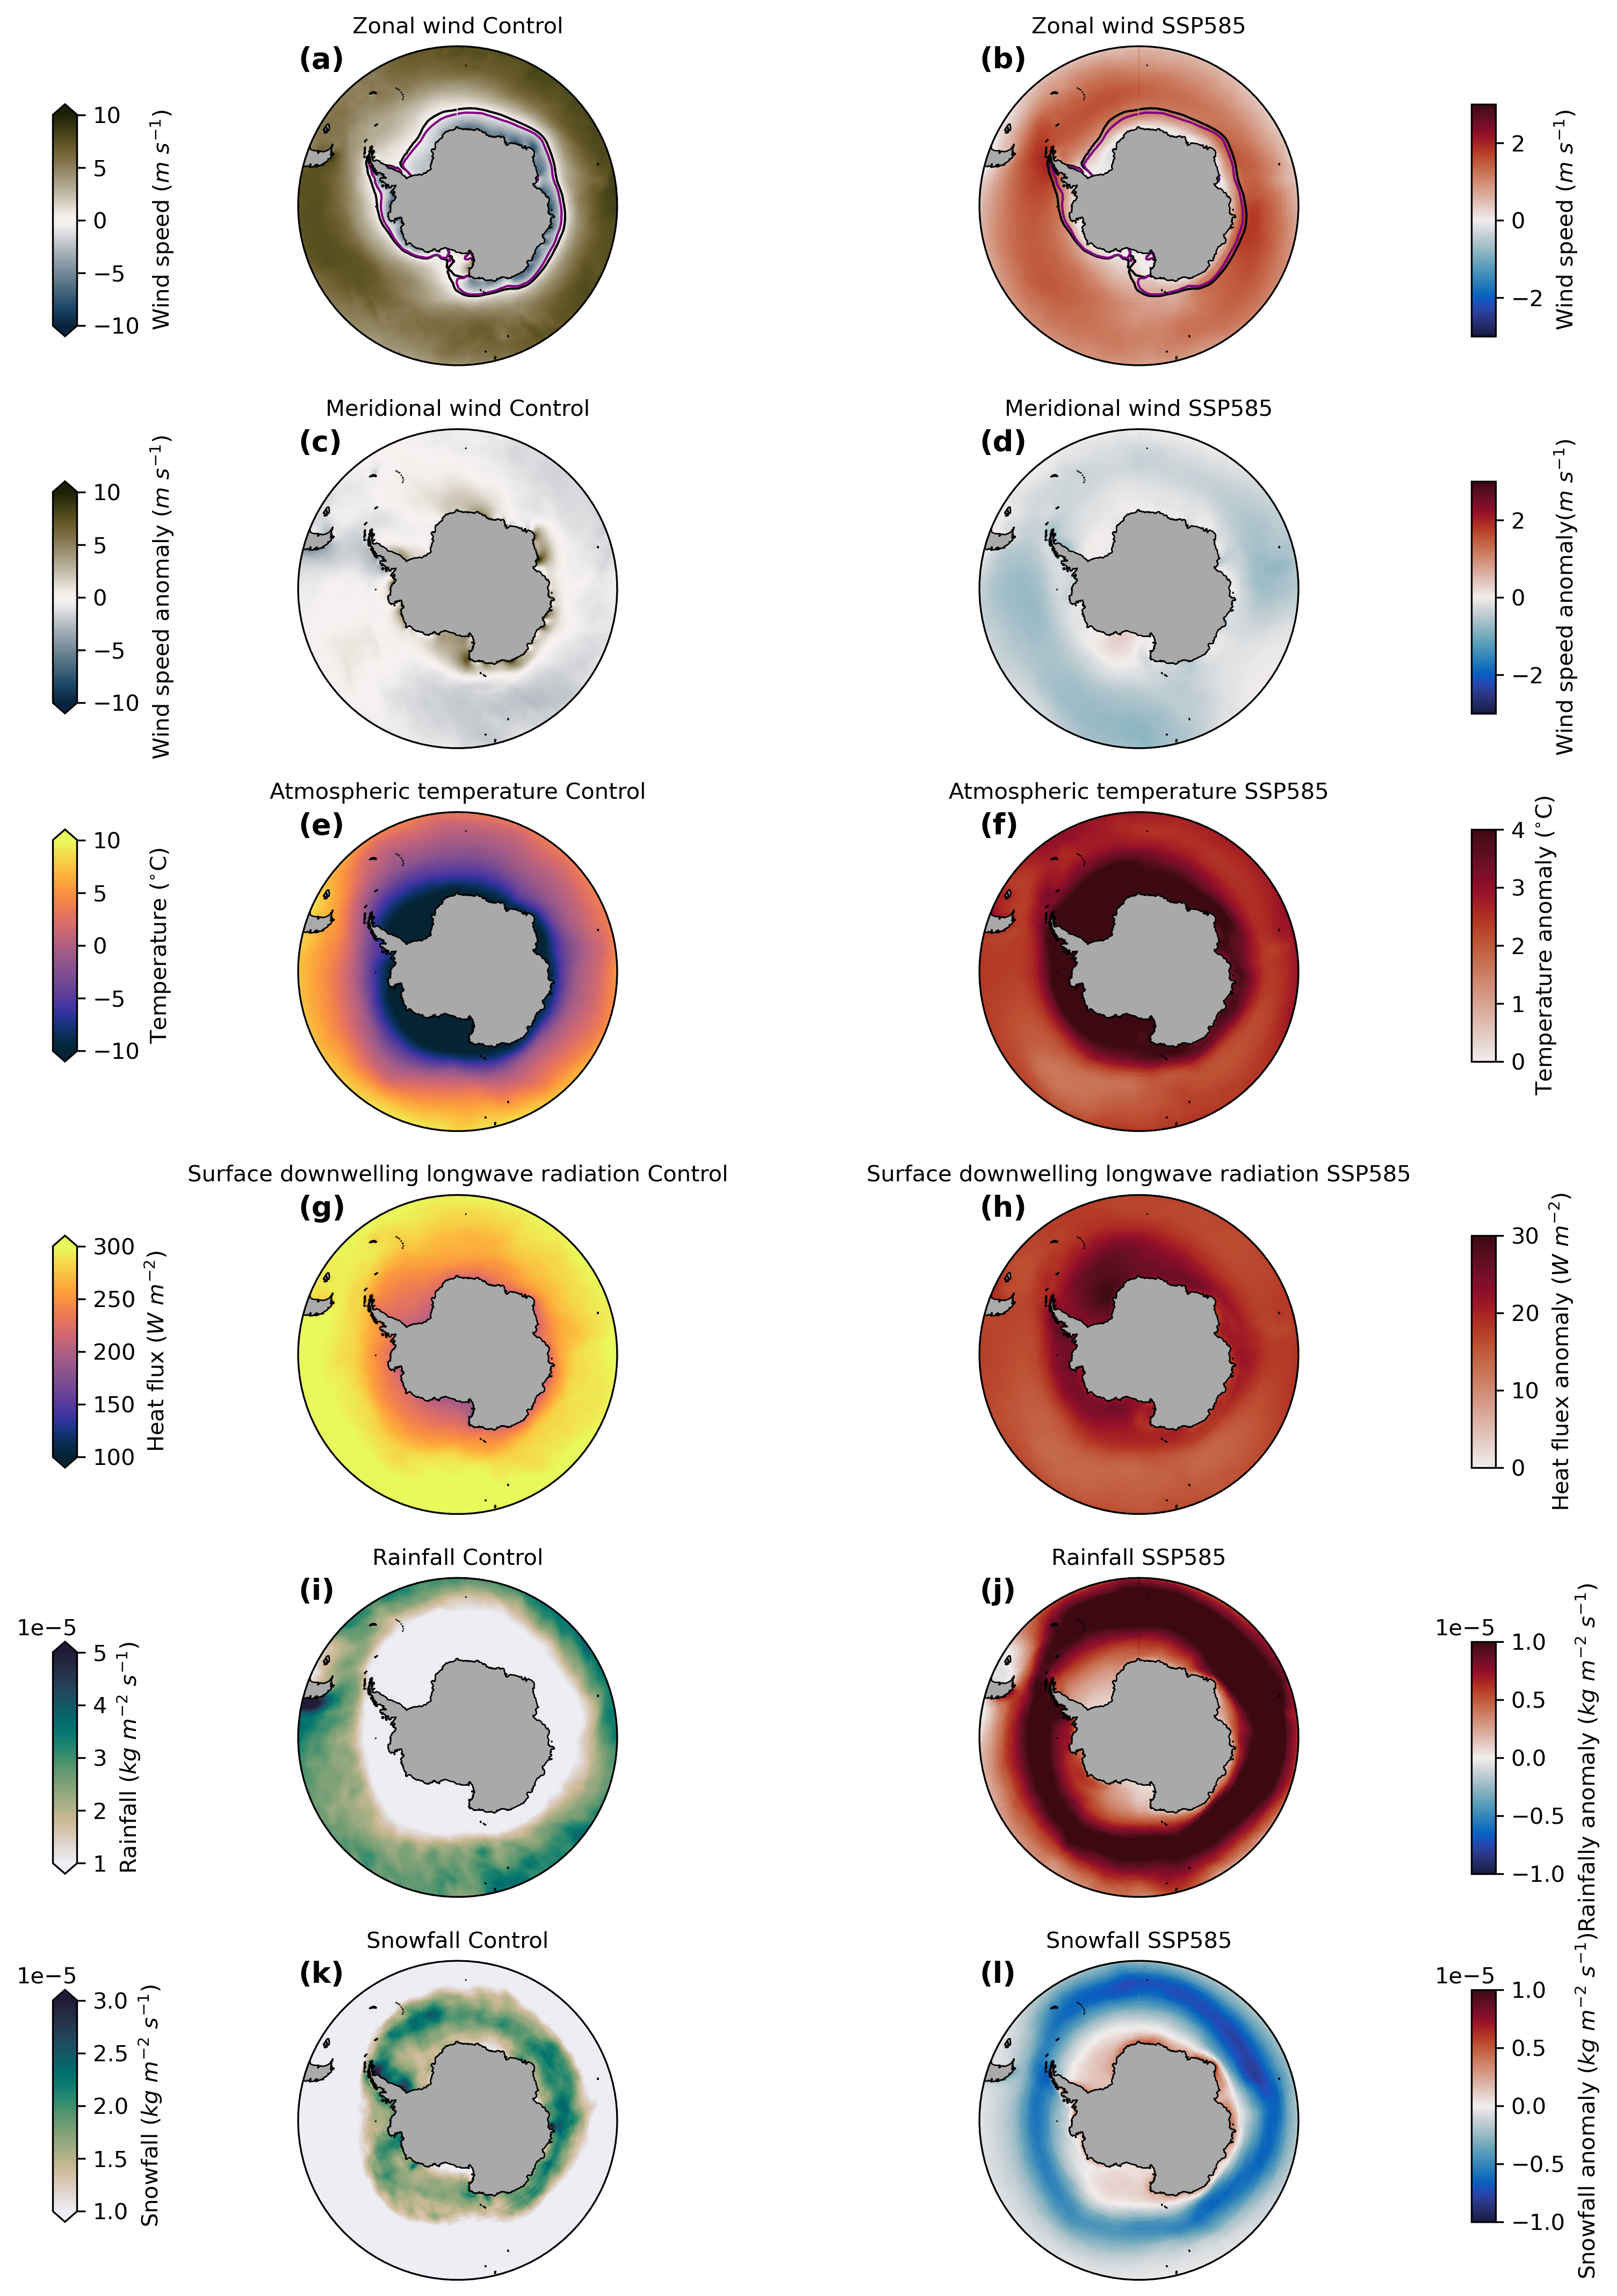

In [16]:
# plot the anomaly
projection = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(10, 18),dpi=300)
for i in range(1):
    for j in range(12):
        variable_name = ['Zonal wind Control','Zonal wind SSP585','Meridional wind Control','Meridional wind SSP585',
                        'Atmospheric temperature Control','Atmospheric temperature SSP585','Surface downwelling longwave radiation Control','Surface downwelling longwave radiation SSP585',
                        'Rainfall Control','Rainfall SSP585','Snowfall Control','Snowfall SSP585']
        order = order = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)',][j]
        projection=ccrs.SouthPolarStereo()
        ax = plt.subplot(6,2,j+1,projection = projection,facecolor="darkgrey")
        theta = np.linspace(0,2*np.pi,100)
        center,radius = [0.5, 0.5], 0.5
        verts = np.vstack([np.sin(theta), np.cos(theta)]).T
        circle = mpath.Path(verts * radius + center)
        ax.set_boundary(circle, transform=ax.transAxes)
        if j==0:
            p1 = data[variable_name[j]].plot(ax=ax, vmin = -10,vmax = 10, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.diff,add_colorbar = False)
            uas_ctrl.plot.contour(ax=ax, levels = [0.1], transform=ccrs.PlateCarree(),linewidths = 1.0,colors='k')
            uas_th.plot.contour(ax=ax, levels = [0.1], transform=ccrs.PlateCarree(),linewidths = 1.0,colors='purple')
        elif j==1:
            p2 = data[variable_name[j]].plot(ax=ax, vmin = -3,vmax = 3, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.balance,add_colorbar = False)
            uas_ctrl.plot.contour(ax=ax, levels = [0.1], transform=ccrs.PlateCarree(),linewidths = 1.0,colors='k')
            uas_th.plot.contour(ax=ax, levels = [0.1], transform=ccrs.PlateCarree(),linewidths = 1.0,colors='purple')
        if j==2:
            p3 = data[variable_name[j]].plot(ax=ax, vmin = -10,vmax = 10, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.diff,add_colorbar = False)
        elif j==3:
            p4 = data[variable_name[j]].plot(ax=ax, vmin = -3,vmax = 3, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.balance,add_colorbar = False)
        if j==4:
            p5 = data[variable_name[j]].plot(ax=ax, vmin = -10,vmax = 10, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.thermal,add_colorbar = False)
        elif j==5:
            p6 = data[variable_name[j]].plot(ax=ax, vmin = 0,vmax = 4, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.amp,add_colorbar = False)
        if j==6:
            p7 = data[variable_name[j]].plot(ax=ax, vmin = 100,vmax = 300, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.thermal,add_colorbar = False)
        elif j==7:
            p8 = data[variable_name[j]].plot(ax=ax, vmin = 0,vmax = 30, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.amp,add_colorbar = False)

        if j==8:
            p9 = data[variable_name[j]].plot(ax=ax, vmin = 1e-5,vmax = 5e-5, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.rain,add_colorbar = False)
        elif j==9:
            p10 = data[variable_name[j]].plot(ax=ax, vmin = -1e-5,vmax =1e-5, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.balance,add_colorbar = False)

        if j==10:
            p11 = data[variable_name[j]].plot(ax=ax, vmin = 1e-5,vmax = 3e-5, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.rain,add_colorbar = False)
        elif j==11:
            p12 = data[variable_name[j]].plot(ax=ax, vmin = -1e-5,vmax =1e-5, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.balance,add_colorbar = False)
        land[0,:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
        land[0,:,:].fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
                            transform=ccrs.PlateCarree(), add_colorbar=False,linewidths = 0.6)
        #plt.plot(x_shelf, y_shelf, linewidth=0.5,color='black',transform=ccrs.PlateCarree())
        ax.set_title(f'{variable_name[j]}', fontsize = 10)
        ax.text(
        0.0, 1., f'{order}', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
        )
        #fig.suptitle('Wind fields', fontsize=16)
    ax_cb1 = plt.axes([0.05, 0.78, 0.015, 0.08])
    cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
    cb.ax.set_ylabel('Wind speed ($m\ s^{-1}$)', fontsize = 10)
    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')

    # colorbar 
    ax_cb2 = plt.axes([0.93, 0.78, 0.015, 0.08])
    cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='neither')
    cb.ax.set_ylabel('Wind speed ($m\ s^{-1}$)', fontsize = 10)
    
    ax_cb1 = plt.axes([0.05, 0.65, 0.015, 0.08])
    cb = plt.colorbar(p3, cax=ax_cb1,  orientation='vertical',extend='both')
    cb.ax.set_ylabel('Wind speed anomaly ($m\ s^{-1}$)', fontsize = 10)
    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')

    # colorbar 
    ax_cb2 = plt.axes([0.93, 0.65, 0.015, 0.08])
    cb = plt.colorbar(p4, cax=ax_cb2,  orientation='vertical',extend='neither')
    cb.ax.set_ylabel('Wind speed anomaly($m\ s^{-1}$)', fontsize = 10)

    ax_cb1 = plt.axes([0.05, 0.53, 0.015, 0.08])
    cb = plt.colorbar(p5, cax=ax_cb1,  orientation='vertical',extend='both')
    cb.ax.set_ylabel('Temperature ($^{\circ}$C)', fontsize = 10)
    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')

    # colorbar 
    ax_cb2 = plt.axes([0.93, 0.53, 0.015, 0.08])
    cb = plt.colorbar(p6, cax=ax_cb2,  orientation='vertical',extend='neither')
    cb.ax.set_ylabel('Temperature anomaly ($^{\circ}$C)', fontsize = 10)

    ax_cb1 = plt.axes([0.05, 0.39, 0.015, 0.08])
    cb = plt.colorbar(p7, cax=ax_cb1,  orientation='vertical',extend='both')
    cb.ax.set_ylabel('Heat flux ($W\ m^{-2}$)', fontsize = 10)
    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')

    # colorbar 
    ax_cb2 = plt.axes([0.93, 0.39, 0.015, 0.08])
    cb = plt.colorbar(p8, cax=ax_cb2,  orientation='vertical',extend='neither')
    cb.ax.set_ylabel('Heat fluex anomaly ($W\ m^{-2}$)', fontsize = 10)

    ax_cb1 = plt.axes([0.05, 0.25, 0.015, 0.08])
    cb = plt.colorbar(p9, cax=ax_cb1,  orientation='vertical',extend='both')
    cb.ax.set_ylabel('Rainfall ($kg\ m^{-2}\ s^{-1}$)', fontsize = 10)
    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')

    # colorbar 
    ax_cb2 = plt.axes([0.93, 0.25, 0.015, 0.08])
    cb = plt.colorbar(p10, cax=ax_cb2,  orientation='vertical',extend='neither')
    cb.ax.set_ylabel('Rainfally anomaly ($kg\ m^{-2}\ s^{-1}$)', fontsize = 10)

    ax_cb1 = plt.axes([0.05, 0.13, 0.015, 0.08])
    cb = plt.colorbar(p11, cax=ax_cb1,  orientation='vertical',extend='both')
    cb.ax.set_ylabel('Snowfall ($kg\ m^{-2}\ s^{-1}$)', fontsize = 10)
    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')

    # colorbar 
    ax_cb2 = plt.axes([0.93, 0.13, 0.015, 0.08])
    cb = plt.colorbar(p12, cax=ax_cb2,  orientation='vertical',extend='neither')
    cb.ax.set_ylabel('Snowfall anomaly ($kg\ m^{-2}\ s^{-1}$)', fontsize = 10)